In [1]:
import numpy as np
from numpy.typing import NDArray # type annotation
from scipy.special import factorial2 # doble factorial
from scipy.special import sph_harm_y as sph_harm # armónicos esféricos
# función de error
from scipy.optimize import minimize
from scipy.integrate import quad

import sys

# funciones personalizadas para graficar
from H2.graficar import plt, compararSTO

# STO-3G

El presente archivo da una explicación del cálculo para la aproximación de una función de tipo Slater (STO, del inglés *Slater Type Orbital*) mediante una $k$-contracción Gaussiana. En particular, se aproxima al STO del átomo de hidrógeno, una función $1\mathrm{s}$ mediante una 3-contracción Gaussiana.

---

## Definiciones

<div class="alert alert-block alert-info">
    <strong>Función de tipo Slater</strong>
</div>

$$ \chi_{nlm}^{\mathrm{STO}}(\zeta, r, \theta, \phi) = R_{n}^{\mathrm{STO}}(\zeta, r) Y_{lm}(\theta, \varphi)\,; \qquad
R_{n}^{\mathrm{STO}}(\zeta, r) = \frac{(2\zeta)^{3/2}}{\sqrt{(2n)!}} (2 \zeta r)^{n-1} \exp(-\zeta r)
$$

In [2]:
def R_STO(n: int, ζ: float, r: NDArray) -> NDArray:
    """ Función radial de tipo Slater

    Parámetros
        n : número cuántico principal
        ζ : exponente oribital de Slater
        r : coordenada radial
    """
    return np.power(2*ζ, 1.5) / np.sqrt(factorial2(2*n)) * np.power(2*ζ*r, n-1) * np.exp(-ζ*r)

In [3]:
def χ_STO(n: int, l: int, m: int, ζ: float, r: NDArray, θ: NDArray, ϕ: NDArray) -> NDArray:
    """ Función de tipo Slater (Slater Type Orbital)

    Parámetros
        (n, l, m) : número cuántico (principal, azimutal, magnético)
        ζ : exponente orbital de Slater
        (r, θ, ϕ) : coordenada (radial, polar, azimutal)
    """
    return R_STO(n, ζ, r) * sph_harm(l, m, ϕ, θ)

<div class="alert alert-block alert-info">
    <strong>Función de tipo Gaussiana</strong>
</div>

$$ \chi_{nlm}^{\mathrm{GTO}}(\zeta, r, \theta, \phi) = R_l^{\mathrm{GTO}} (\alpha, r) Y_{lm}(\theta, \varphi) \,; \qquad
R_l^{\mathrm{GTO}} (\alpha, r) = \frac{2(2\alpha)^{3/4}}{\pi^{1/4}} \sqrt{\frac{2^l}{(2l+1)!!}} (\sqrt{2\alpha}r)^l \exp(-\alpha r^2)
$$

In [4]:
def R_GTO(l: int, α: float, r: NDArray) -> NDArray:
    """ Función radial de tipo Guassiana

    Parámetros
        n : número cuántico principal
        α : exponente orbital Gaussiano
        r : coordenada radial
    """
    m1: float = 2*np.power(2*α, 0.75) / np.power(np.pi, 0.25)
    m2: float = np.sqrt(np.power(2,l) / factorial2(2*l+1))
    m3: NDArray = np.power(np.sqrt(2*α)*r, l)
    m4: NDArray = np.exp(-α*np.power(r,2))
    return m1 * m2 * m3 * m4

In [5]:
def χ_GTO(l: int, m: int, α: float, r: NDArray, θ: NDArray, ϕ: NDArray) -> NDArray:
    """ Función de tipo Gaussiana (Gaussian Type Orbital)

    Parámetros
        (l, m) : número cuántico (azimutal, magnético)
        α : exponente orbital Gaussiano
        (r, θ, ϕ) : coordenada (radial, polar, azimutal)
    """
    return R_GTO(l, α, r) * sph_harm(l, m, ϕ, θ)

<div class="alert alert-block alert-info">
    <strong>Funciones $1\mathrm{s}$</strong>
</div>

In [6]:
n: int = 1 # no. cuántico principal
l: int = 0 # no. cuántico azimutal
m: int = 0 # no. cuántico magnético

El armónico esférico con $l=0\,$ y $\,m=0$ es $Y_{00}(\theta,\phi) = \frac{1}{2} \sqrt{\frac{1}{\pi}}$, para toda pareja de valores $(\theta,\phi)$. Por lo tanto se considerará una pareja arbitraria $(\theta,\phi)$ para la construcción de la función $\chi_{1s}^{STO}(r,\theta,\phi)$.

In [7]:
r: NDArray = np.linspace(0, 4, 100) # coordenada radial
θ: NDArray = np.zeros(100) # coordenada polar
ϕ: NDArray = np.zeros(100) # coordenada azimutal

In [8]:
# Función |1s> de tipo Slater
ζ: float = 1.0 # exponente orbital de Slater
χ_STO_1s: NDArray = np.real(χ_STO(n, l, m, ζ, r, θ, ϕ))

# Función |1s> de tipo Gaussiano
α: float = 1.0 # exponente orbital Gaussiano
χ_GTO_1s: NDArray = np.real(χ_GTO(l, m, α, r, θ, ϕ))

A continuación una comparación visual de las funciones $\ket{1\mathrm{s}}$ de tipo Slater ($\zeta = 1$) y Gaussiana ($\alpha = 1$).

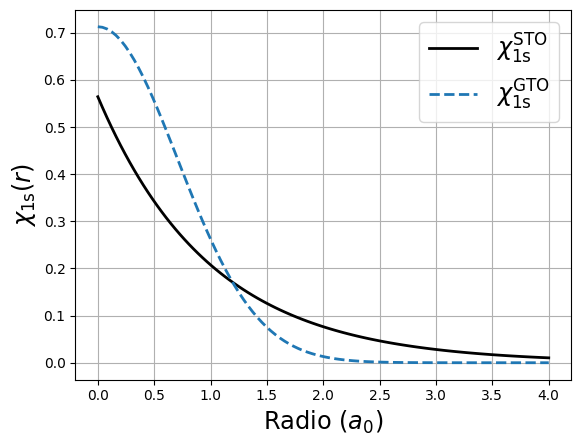

In [9]:
# Graficar STO y GTO para 1s
plt.plot(r, χ_STO_1s, label=r'$\chi_{1\mathrm{s}}^{\mathrm{STO}}$', color='k', linewidth=2)
plt.plot(r, χ_GTO_1s, label=r'$\chi_{1\mathrm{s}}^{\mathrm{GTO}}$', linestyle='dashed', linewidth=2)

plt.xlabel('Radio ($a_0$)', fontsize='xx-large')
plt.ylabel(r'$\chi_{1\mathrm{s}}(r)$', fontsize='xx-large')
plt.grid()
plt.legend(fontsize='xx-large')
plt.show()

---
## Contracción Gaussiana: STO-$k$G <a class="anchor" id="section_2"></a>

Se busca aproximar a la función original de tipo Slater `STO(n, l, m, ζ, r, θ, ϕ)` planteando a la parte radial de la misma como una combinación lineal de $k$ funciones Gaussianas, i.e.
$$
R_{n}^{\mathrm{STO}} (\zeta, r) \approx R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r) = \sum_{i=1}^{k} d_i R_{l}^{\mathrm{GTO}} (\zeta^2 \alpha_i, r) \,,
$$

de lo cual la aproximación para la función original de tipo Slater luciría como:
$$ \chi_{nlm}^{\mathrm{STO}}(\zeta, \vec{d}, \vec{\alpha}, r, \theta, \phi)
\approx \chi_{nlm}^{k}(\zeta, \vec{d}, \vec{\alpha}, r, \theta,\phi)
= R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r) Y_{lm}(\theta,\phi)$$

In [10]:
def R_STO_kG(ζ: float, d: NDArray, a: NDArray, l: int, r: NDArray) -> NDArray:
    """ Combinación lineal de Gaussianas (parte radial)

    Parámetros
        ζ : exponente orbital de Slater
        d : vector de coeficientes de expansión (d1, d2, ..., dk)
        a : vector de exponentes orbitales Gaussianos (α1, α2, ..., αk)
        l : número cuántico azimutal
        r : coordenada radial
    """
    suma: float = 0.0
    # calcular cada uno de los k términos de la combinación lineal
    for di, αi in zip(d, a):
        suma += di * R_GTO(l, np.power(ζ,2)*αi, r) # k-ésimo término
    
    return suma

In [11]:
def χ_STO_kG(ζ: float, d: NDArray, a: NDArray, l: int, m: int, r: NDArray, θ: float, ϕ: float) -> NDArray:
    """ Combinación lineal de 'k' Gaussianas

    Parámetros
        ζ : exponente orbital de Slater
        d : vector de coeficientes de expansión (d1, d2, ..., dk)
        a : vector de exponentes orbitales Gaussianos (α1, α2, ..., αk)
        (l, m) : número cuántico (azimutal, magnético)
        (r, θ, ϕ) : coordenada (radial, polar, azimutal)
    """
    suma: float = 0.0
    for di, αi in zip(d, a): # calcular cada uno de los k términos de la suma
        suma += di * χ_GTO(l, m, np.power(ζ,2)*αi, r, θ, ϕ) # término k-ésimo
    
    return suma

<div class="alert alert-block alert-warning">
<strong>Observación.</strong> Conforme el número de términos en la contracción Gaussiana se puede aumentar la precisión de la aproximación tanto para la función original y su distribución radial. Por la literatura [3] se sabe que para aproximar una función $\ket{1\mathrm{s}}$ de Slater, una 3-contracción de Gaussianas es suficiente.
</div>

<div class="alert alert-block alert-info">
    <strong>Condición de normalización</strong>
</div>

Dado que la función original $\chi_{nlm}^{\mathrm{STO}} (\zeta, \vec{d}, \vec{\alpha}, r, \theta, \phi)$ se encuentra normalizada, se impone la condición de normalización para la aproximación de esta, la función $\chi_{nlm}^{k}(\zeta, \vec{d}, \vec{\alpha}, r, \theta,\phi)$:
$$
1 = \langle \, \chi_{nlm}^{k} \, | \, \chi_{nlm}^{k} \, \rangle
= \int r^2 |R_{nl}^{k}|^2 \mathrm{d}r \, \int |Y_{lm}|^2 \, \mathrm{d}\Omega
= \int r^2 \Big|\sum_{i=1}^{k} d_i \, R_{l}^{\mathrm{GTO}} (\zeta^2 \alpha_i, r) \Big|^2 \, \mathrm{d}r \,.
$$

Desarrolando la expresión se llega a que la condición de normalización para la contracción de $k$ Gaussianas es
$$
\begin{align}
\boxed{1 = \sum_{i=1}^{k} d_i^2 + 2 \sum_{i<j} d_i d_j \left( \frac{2}{\alpha_i + \alpha_j} \right)^{l + \frac{3}{2}} (\alpha_i \alpha_j)^{\frac{l}{2} + \frac{3}{4}}}
\end{align}
$$

En este trabajo se buscarán los parámetros para una contracción Gaussiana $\ket{1s}$ de 3 términos. Es decir $k=3$, en cuyo caso la condición de normalización será:
$$
\boxed{
1 = d_1^2 + d_2^2 + d_3^2
+ 2 d_1 d_2 \frac{2^{3/2} (\alpha_1 \alpha_2)^{3/4}}{(\alpha_1 + \alpha_2)^{3/2}}
+ 2 d_1 d_3 \frac{2^{3/2} (\alpha_1 \alpha_3)^{3/4}}{(\alpha_1 + \alpha_3)^{3/2}}
+ 2 d_2 d_3 \frac{2^{3/2} (\alpha_2 \alpha_3)^{3/4}}{(\alpha_2 + \alpha_3)^{3/2}}}
$$

In [12]:
def cond_norm(l: int, d: NDArray, a: NDArray) -> float:
    """ Condición de normalización para una k-contracción de Gaussianas

    Parámetros
        l : número cuántico azimutal, l = 0, 1, ..., n-1
        d : vector de coeficientes de expansión (d1, d2, ..., dk)
        a : vector de exponentes orbitales Gaussianos (α1, α2, ..., αk)
    """
    termino1 = sum(np.square(d))
    termino2 = 0
    
    k = len(d)
    for i in range(k-1):
        for j in range(i+1,k):
            termino2 += d[i] * d[j] * np.power(2/(a[i]+a[j]), l + 3/2) * np.power(a[i]*a[j], l/2 + 3/4)

    return termino1 + 2*termino2

<div class="alert alert-block alert-info">
    <strong>Función de error</strong>
</div>

No solo es relevante los parámetros de la aproximación preserven la normalización, también es importante la función de distribución radial sea preservada. En otras palabras, se busca minimizar a la función de error $\epsilon$ dada por
$$
\epsilon
= \Big\langle f - g \, \Big| \, f - g \Big\rangle
$$

donde $f$ es la función original y $g$ la $k$-contracción Gaussiana, dadas por:
$$
\begin{align}
    f &:= R_{n}^{\mathrm{STO}}(\zeta, r) \\
    g &:= R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r)
\end{align}
$$

No se consideran a las partes angulares de ambas funciones pues los armónicos esféricos están normalizados. Explícitamente, el problema de minimización sería:
$$
\epsilon := \epsilon_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha})
= \Big\langle R_{n}^{\mathrm{STO}}(\zeta, r) - R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r) \, \Big| \,
    R_{n}^{\mathrm{STO}}(\zeta, r) - R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r) \Big\rangle
$$

no obstante, nos restringiremos a usar la primer notación introducida por simplicidad.

Considere el siguiente desarrollo para el problema de minimización en cuestión:
$$
\begin{align}
    \epsilon &= \int |f - g|^2 \,\mathrm{d}\tau
    = 2 - \int g^{*}f \,\mathrm{d}\tau - \int f^{*}g \,\mathrm{d}\tau
\end{align}
$$

Para el caso de una aproximación de una función $\ket{1s}$ de Slater, ambas funciones $f$ y $g$ son reales. Por lo cual el problema de minimización de interés a resolver será:
$$
\begin{align*}
    \epsilon = 2 - 2 \int f \, g \, \mathrm{d}\tau
\end{align*}
$$

Como la función de error $\epsilon$ debe ser minimizada, obtener el máximo para esta última integral (conocida como integral de traslape, $S$ ) es equivalente a resolver el problema original.
$$
\boxed{S = \int_{0}^{\infty} r^2 R_{n}^{\mathrm{STO}}(\zeta, r) \, R_{nl}^{k}(\zeta, \vec{d}, \vec{\alpha}, r) \, \mathrm{d}r}
$$

A partir de la condición de normalización y la maximización de $S$ se cuenta con los criterios necesarios para encontrar los parámetros que ajustarán del mejor modo a la contracción de 3 Gaussianas sobre la función de Slater $\ket{1s}$.

En el trabajo original de 1969 de Robert F. Stewart [3] se explica cómo calcular a los parámetros de la $k$-contracción mediante la matriz de mínimos cuadrados. Para que la función de error $\epsilon$ sea un mínimo respecto a los parámetros Gaussianos $P_j$ (los coeficientes de la contracción $d_j$ y los exponentes orbitales $\alpha_j$) debe ocurrir que $\partial \epsilon / \partial P_j = 0$, con $j = 1, 2, \dots, 2k$. A partir de esto es posible hacer una expansión en Taylor de $\partial \epsilon / \partial P_j$ a primer orden alrededor de un conjunto de parámetros iniciales $\mathbf{P}^0$ y así obtener una ecuación matricial que involucra a la Hessiana de $\epsilon$.

En este trabajo se tomará un camino diferente, en mayor parte gracias a las herramientas computacionales de hoy día. Para determinar a los parámetros de la $k$-contracción emplearemos a la función `minimize` de la paquetería *SciPy* (v1.15.2) la cual toma a la función por minimizar ($\epsilon$), las restricciones a considerar (condición de normalización), el intervalo de los parámetros a considerar ($\alpha_i$ > 0, $\forall \alpha_i$) y un conjunto de parámetros iniciales $\mathbf{P}^0$. Para el conjunto $\mathbf{P}^0$ los valores serán generados a partir de la función `rand()` de *Numpy* (v2.2.3) la cual devuelve un número aleatorio entre 0 y 1.

In [13]:
def f(r: NDArray) -> NDArray:
    """ Función original: R_STO(1s), ζ = 1

    Parámetro
        r : coord. radial
    """
    n: int = 1 # número cuántico principal
    ζ: float = 1.0 # exponente orbital de Slater
    return R_STO(n, ζ, r)

def g(r: NDArray, params: list[float]) -> NDArray:
    """ Aproximación parametrizada: R_STO-3G(1s), ζ = 1

    Parámetro
        r : coord. radial
    """
    d1, d2, d3, a1, a2, a3 = params
    d: list[float] = [d1, d2, d3]
    a: list[float] = [a1, a2, a3]
    ζ: float = 1.0 # exponente orbital de Slater
    return R_STO_kG(ζ, d, a, 0, r) # Note que `R_STO_kG` no está normalizada

def cond(params: list[float]):
    """ Condición de normalización
    """
    d1, d2, d3, α1, α2, α3 = params
    d: list[float] = [d1, d2, d3] # coeficientes de contracción
    a: list[float] = [α1, α2, α3] # exponentes orbitales Gaussianos
    l: int = 0 # número cuántico azimutal
    return cond_norm(l, d, a) - 1

In [14]:
# sys.float_info.epsilon = diferencia más pequeña entre 1 y el siguiente 'float' posible de ser representado
epsilon: float = sys.float_info.epsilon

# Función por minimizar:
def error(params: list[float]):
    """ Función de error
    
    params : (d1, d2, ..., dk, a1, a2, ..., ak)
        di -> coeficiente de contracción
        aj -> exponente orbital Gaussiano
    """
    integrand = lambda x: (x**2) * f(x) * g(x,params)
    integral, _ = quad(integrand, epsilon, np.inf)
    return 2 - 2*integral

<div class="alert alert-block alert-danger">
    <strong>¡Cuidado!</strong> <br>
    Correr la siguiente celda cambiará los parámetros obtenidos.
</div>

In [15]:
params_optimos: list[float] = []
error_Stewart: float = 3.305e-4 # error porcentual de Stewart
error_trabajo: float = 1.0 # error porcentual del presente trabajo (el valor 1 solo es empleado para declarar la variable)

# se corre el programa hasta obtener un error porcentual menor o igual que el de Stewart
while error_trabajo > error_Stewart:
    # vector de parámetros iniciales P^0
    # el orden de los parámetros es (d1, d2, ..., dk, a1, a2, ..., ak)
    params_inicial: list[float] = np.random.rand(1,6)[0].tolist()
    
    # intervalos que toma cada parámetro Gaussiano
    bounds: list[(float, float)] = [(-np.inf, np.inf), (-np.inf, np.inf), (-np.inf, np.inf),
                                    (epsilon, np.inf), (epsilon, np.inf), (epsilon, np.inf)]
    
    # restricciones del problema (condición de normalización)
    con = {'type': 'eq', 'fun': cond}

    # minimización
    result3G = minimize(error, params_inicial, bounds=bounds, constraints=[con])
    error_trabajo = result3G.fun

print(f"La función de error ha sido minimizada.")

La función de error ha sido minimizada.


In [16]:
d3G: NDArray = result3G.x[:len(result3G.x)//2] # coeficientes de contracción
a3G: NDArray = result3G.x[len(result3G.x)//2:] # exponentes orbitales
l: int = 0 # no. cuántico azimutal

print("Parámetros iniciales:", params_inicial)
print("Parámetros óptimos:", result3G.x)
print("Error en la condición de normalización:", abs((cond_norm(l, d3G, a3G)-1)*100), "%")
print("Valor función de error:", result3G.fun)

Parámetros iniciales: [0.6354583778897152, 0.9243956700231839, 0.6529981010573492, 0.4214116868356884, 0.07227245582486441, 0.8774062071840688]
Parámetros óptimos: [0.53517691 0.44508074 0.15404363 0.40625535 0.10988261 2.23163213]
Error en la condición de normalización: 7.374927177838941e-05 %
Valor función de error: 0.000329793574884496


---
## STO-3G en la literatura <a class="anchor" id="section_3"></a>

En esta sección se determinará el error en la condición de normalización y el valor de la función de error a partir de los parámetros $P_j$ reportados por Stewart [3, pág. 2487]. Mas aún, se compararán visualmente las funciones radiales y de distribución radial obtenidas en el presente trabajo y las de Stewart.

A continuación los parámetros reportados por Stewart y aquellos encontrados en el presente trabajo.
<table>
    <thead>
        <tr>
        <th style="text-align:left">Parámetro</th>
        <th style="text-align:center">$d_1$</th>
        <th style="text-align:center">$d_2$</th>
        <th style="text-align:center">$d_3$</th>
        <th style="text-align:center">$\alpha_1$</th>
        <th style="text-align:center">$\alpha_2$</th>
        <th style="text-align:center">$\alpha_3$</th>
        </tr>
    </thead>
    <tbody>
    <tr>
        <td style="text-align:left">Stewart</td>
        <td style="text-align:center">0.444635</td>
        <td style="text-align:center">0.535328</td>
        <td style="text-align:center">0.154329</td>
        <td style="text-align:center">0.109818</td>
        <td style="text-align:center">0.405771</td>
        <td style="text-align:center">2.22766</td>
    </tr>
    <tr>
        <td style="text-align:left">Este trabajo</td>
        <td style="text-align:center">0.445081</td>
        <td style="text-align:center">0.535177</td>
        <td style="text-align:center">0.154044</td>
        <td style="text-align:center">0.109883</td>
        <td style="text-align:center">0.406255</td>
        <td style="text-align:center">2.23163</td>
        </tr>
    </tbody>
</table>


Cabe ser mencionado que todos los valores pertenecientes a este trabajo reportados en las tablas previas están redondeados a 6 cifras de precisión decimal para coincidir en longitud con los reportados por Stewart. Los valores reales poseen una precisión decimal de 17 dígitos y se encuentran impresos al final de este archivo de Jupyter en el *Apéndice*.

Los parámetros de Stewart y los hayados son tan cercanos que no es posible apreciar una diferencia entre las curvas generadas a partir de dichos parámetros.

A continuación se reportan el error porcentual de la condición de normalización y el valor de la función de error.
<table>
    <thead>
        <tr>
            <th style="text-align:left">Valor</th>
            <th style="text-align:left">Normalización</th>
            <th style="text-align:left">Error</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:left">Stewart</td>
            <td style="text-align:left">1.426e-4 %</td>
            <td style="text-align:left">3.305e-4</td>
        </tr>
        <tr>
            <td style="text-align:left">Este trabajo</td>
            <td style="text-align:left">7.375e-5 %</td>
            <td style="text-align:left">3.298e-4</td>
        </tr>
    </tbody>
</table>

<div class='alert alert-block alert-warning'>
    Los parámetros fueron obtenidos a partir de considerar al exponente orbital de Slater como $\zeta = 1$. Sin embargo, el exponente usual para la base de funciones $1\mathrm{s}$ del hidrógeno es $\zeta = 1.24$ [2, p.159].
</div>

Considerando esto último, es necesario ajustar de forma adecuada los parámetros. Afortunadamente, la relación es escalamiento [2, p.158] nos dice que los nuevos exponentes orbitales Gaussianos $\alpha_i$ serán de la forma:

$$ \alpha_i = \alpha_i(\zeta = 1) \times \zeta^2 $$

In [17]:
a3G*np.square(1.24)

array([0.62465822, 0.1689555 , 3.43135756])

De lo cual, los parámetros para $\zeta=1.24$ serían entonces
|  Parámetro  |    $d_1$   |    $d_2$   |    $d_3$   | $\alpha_1$ | $\alpha_2$ | $\alpha_3$ |
|:------------|:----------:|:----------:|:----------:|:----------:|:----------:|:----------:|
| Szabo y Ostlund| 0.444635 | 0.535328 | 0.154329 | 0.168856 | 0.623913 | 3.42525 |
| Este trabajo| 0.444718   | 0.535272   | 0.154300   | 0.168956 | 0.624658 | 3.43136 |

---

## Visualización

In [18]:
# parámetros
n, l, m = 1, 0, 0
z = 1 # exponente orbital de tipo Slater

# Parámetros obtenidos por Stewart
dSte = [0.154329, 0.535328, 0.444635]
aSte = [2.22766, 0.405771, 0.109818]

# Parámetros reportados por Szabo y Ostlund
dSO = [0.154329, 0.535328, 0.444635]
aSO = [3.42525, 0.623913, 0.168856]

In [19]:
# conjunto de datos
xdata: NDArray = np.linspace(0,4,100)
ySlater: NDArray = R_STO(n, z, xdata)
yStewart: NDArray = R_STO_kG(n, dSte, aSte, l, xdata)
ySTO3G: NDArray = R_STO_kG(n, d3G, a3G, l, xdata) # este trabajo

Slater: dict = {'x':xdata, 'y':ySlater, 'label':'Slater', 'color':'k'}
Stewart: dict = {'y':yStewart, 'label':'Stewart', 'linestyle':'--', 'linewidth':2.5, 'marker':None, 'markersize':0, 'color':'blue', 'N':1}
STO3G: dict = {'y':ySTO3G, 'label':'Este trabajo', 'linestyle':'None', 'linewidth':None, 'marker':'o', 'markersize':7, 'color':'red', 'N':5} # este trabajo
datasets: list = [Stewart, STO3G]

xticks: list[NDArray] = [np.arange(0,4.1,0.5), np.arange(0,4.1,0.5)]
yticks: list[NDArray] = [np.arange(0,2.1,0.25), np.arange(0,7.1,1)]

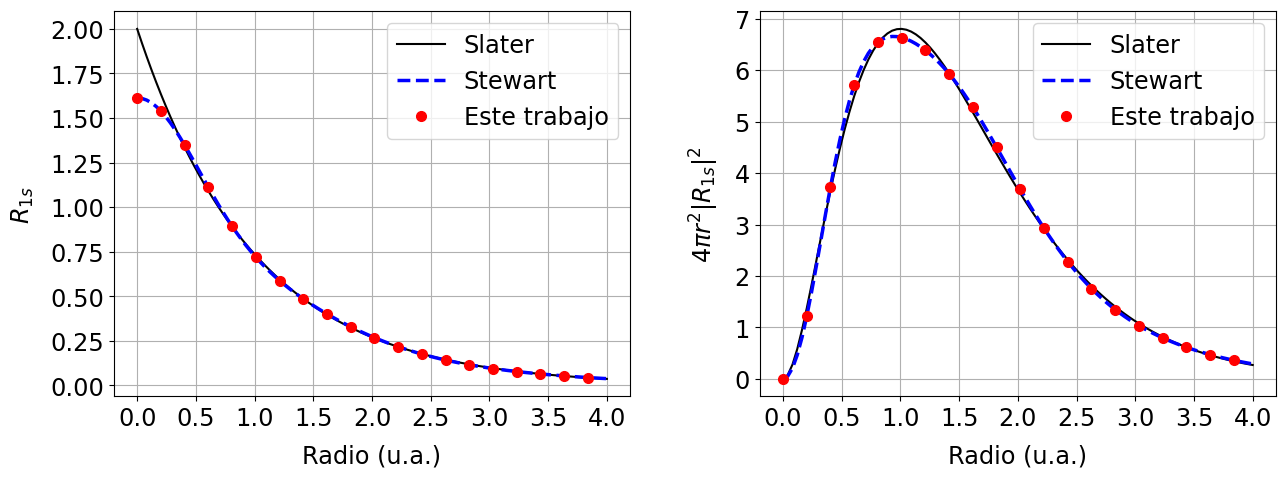

In [20]:
# graficar función
nombre: str = 'SSS'
formato: str = 'svg'
compararSTO(None, formato, Slater, datasets, xticks, yticks)

In [21]:
# parámetros y conjuntos de datos

ζ = 1.24 # exponente orbital de tipo Slater
a3G_2: NDArray = a3G*np.square(ζ)

xdata: NDArray = np.linspace(0,4,100)
ySlater: NDArray = R_STO(n, ζ, xdata) # función radial de tipo Slater |1s>
ySzabo: NDArray = R_STO_kG(n, dSO, aSO, l, xdata)
ySTO3G: NDArray = R_STO_kG(n, d3G, a3G_2, l, xdata) # este trabajo

Slater: dict = {'x':xdata, 'y':ySlater, 'label':'Slater', 'color':'k'}
Szabo: dict = {'y':ySzabo, 'label':'Szabo y Ostlund', 'linestyle':'--', 'linewidth':2.5, 'marker':None, 'markersize':0, 'color':'purple', 'N':1}
STO3G: dict = {'y':ySTO3G, 'label':'Este trabajo', 'linestyle':'None', 'linewidth':None, 'marker':'o', 'markersize':7, 'color':'darkcyan', 'N':5} # este trabajo
datasets: list = [Szabo, STO3G]

xticks: list[NDArray] = [np.arange(0,4.1,0.5), np.arange(0,4.1,0.5)]
yticks: list[NDArray] = [np.arange(0,2.7,0.5), np.arange(0,8.5,2)]

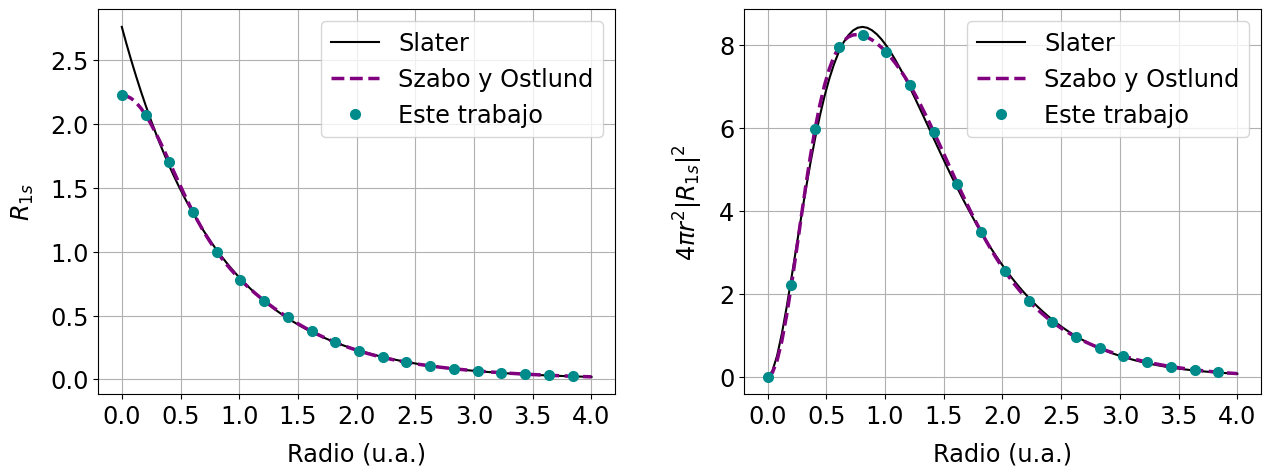

In [22]:
# graficar función
nombre, formato = 'SSS', 'svg'
compararSTO(None, formato, Slater, datasets, xticks, yticks)

---
## Referencias <a class="anchor" id="referencias"></a>

[1] T. Helgaker, P. Jorgensen and J. Olsen, Molecular Electronic-Structure Theory (John Wiley and Sons, Chichester, UK, 2000).

[2] A. Szabo and N. Ostlund, Modern Quantum Chemistry: Introduction to Advanced Electronic Structure Theory (Dover Publications, Mineola, NY, 1996).

[3] Robert F. Stewart. Small Gaussian Expansions of Atomic Orbitals. The Journal of Chemical Physics 50, 2485 (1969); doi: 10.1063/1.1671406

---
## Apéndice <a class="anchor" id="apendice"></a>

Se reportan los valores completos de los coeficientes de contracción $d_i$ y de los exponentes orbitales Gaussianos $\alpha_i$ para un STO-3G con $\zeta=1$.

In [23]:
np.set_printoptions(threshold=np.inf) # remueve el truncamiento al imprimir arreglos
a3G_2: NDArray = np.array(a3G)*np.square(1.24) # relación de escalamiento
d, a, a2 = d3G.tolist(), a3G.tolist(), a3G_2.tolist()

print("Coeficientes de contracción:", d)
print("Exponentes orbitales Gaussianos (Z=1):", a)
print("Exponentes orbitales Gaussianos (Z=1.24):", a2)

Coeficientes de contracción: [0.5351769086493029, 0.4450807404799418, 0.15404363146493988]
Exponentes orbitales Gaussianos (Z=1): [0.4062553490440166, 0.10988260912630128, 2.2316321261965975]
Exponentes orbitales Gaussianos (Z=1.24): [0.6246582246900799, 0.16895549979260086, 3.4313575572398882]


Se reportan los valores completos de los coeficientes de contracción $d_i$ y de los exponentes orbitales Gaussianos $\alpha_i$ para un STO-3G con $\zeta=1.24$.

In [24]:
# guardar valores obtenidos

from H2.utils import guardar

valores: dict = {
    "d1": d[0], "d2": d[1], "d3": d[2], # coeficientes de contracción
    "a1": a[0], "a2": a[1], "a3": a[2], # exponentes orbitales Gaussianos (Z=1)
    "a1_2": a2[0], "a2_2": a2[1], "a3_2": a2[2], # exponentes orbitales Gaussianos (Z=1.24)
}

guardar("H2_STO3G.csv", valores)